## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [1]:
# get data

import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.

Done.

2. Maxmin normalize `year` and `mileage`.

Done.


3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.

Done.

4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

From $k=3-100$, the mean squared error values are decreasing. At $k=300$, the mean squared error value increases.

5. Determine the optimal $k$ for these data.

The optimal $k$ value is the one with the lowest mean squared error. In our case, it is $k = 100$.

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

As $k$ increases, the predicted values seems to approach the mean (30000), indicating the underfitting of the model. A low $k$ value means that each estimation is highly sensitive to its neighbors, leading to wildly swinging values and overfitting.

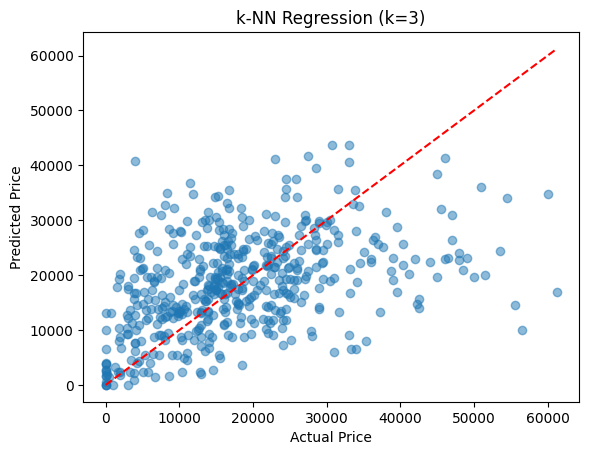

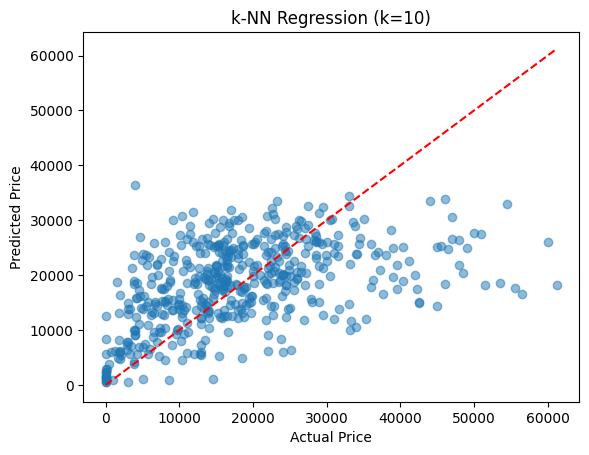

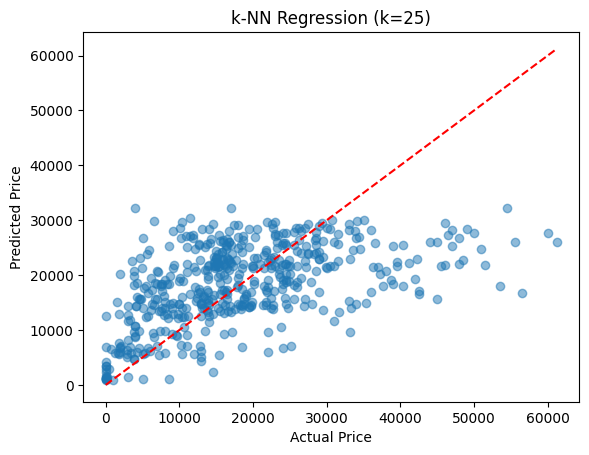

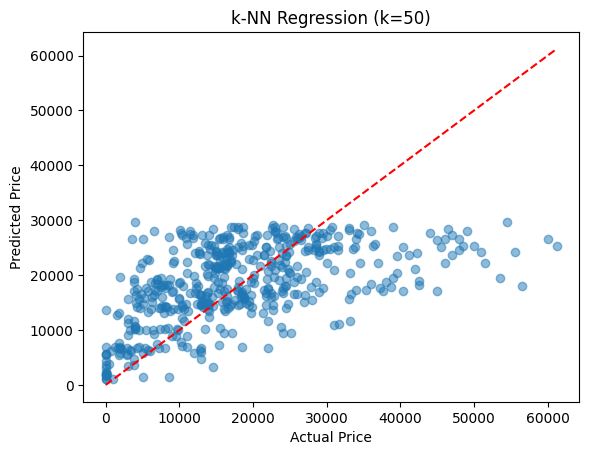

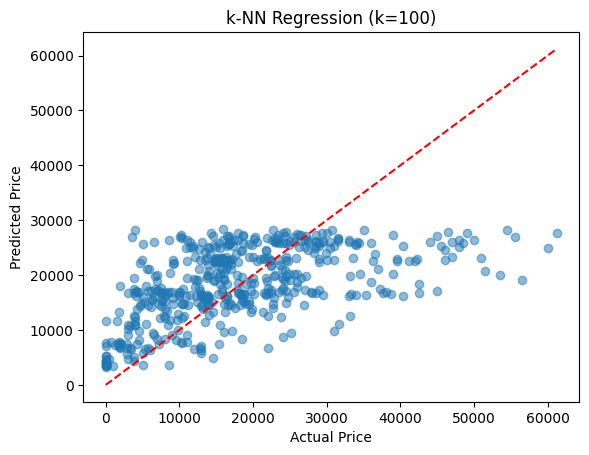

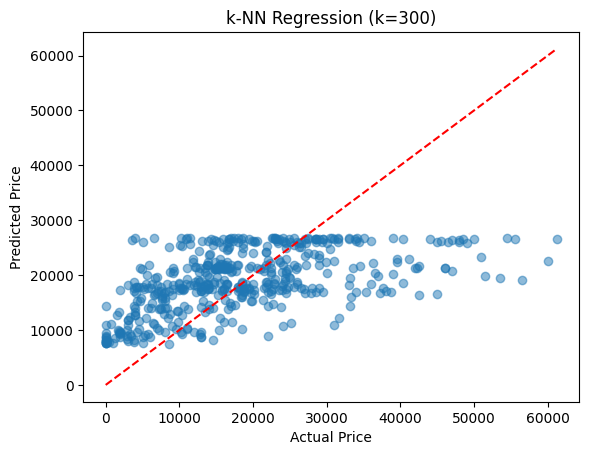

k value = 3, mean squared error = 126446573.21822222
k value = 10, mean squared error = 110802185.58681999
k value = 25, mean squared error = 103170457.848608
k value = 50, mean squared error = 99694130.3796272
k value = 100, mean squared error = 98271058.96092059
k value = 300, mean squared error = 100477298.914212


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('./data/USA_cars_datasets.csv')
df = df.drop(columns=['Unnamed: 0', 'brand', 'model', 'title_status', 'color', 'vin', 'lot', 'state', 'country', 'condition'])

def minmax(x):
    return (x-min(x))/(max(x)-min(x))
X = df[['year', 'mileage']]
scaler = MinMaxScaler()
u = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(u, y, test_size=0.2, random_state = 100)

k_list = [3,10,25,50,100,300]
mse_list = []

for k in k_list:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    mse = mean_squared_error(y_test, y_hat)
    mse_list.append(mse)

    plt.figure()
    plt.scatter(y_test, y_hat, alpha=0.5)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k-NN Regression (k={k})")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], color='red', linestyle='--')
    plt.show()

for i in range(len(k_list)):
  print(f"k value = {k_list[i]}, mean squared error = {mse_list[i]}")



**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?

The dictionary `class_mapping` was generated to map every integer in `class` to its classification value. A large chunk of the data is mammals (41), followed by birds (20). This distribution of values shows that smaller k values will most likely perform better, as there are certain classes that are smaller than the k values in the lists, so their predictions will be skewed.

2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

Done.

3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.

Multiple k values were iterated through to test which would be the best. As expected, the smallest values (k=3) performed the best.

4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?

For this classifier, mistakes were made because there are certain characteristics that overlap across categories. For instance, the invertebrates have many different numbers of legs (0,2,8) across categories. For the octopus, it was similar to the insect category in that they both have 8 legs, no hair, no milk, and no feathers (amongst others). With these overlaps, miscategorization occurred. Specifically, with this classifier we can see misclassifications between categories that are fairly similar, like amphibian-reptile, amphibian-invertebrate, and invertebrate-insect. This implies that the available features are not sufficient to distinguish between these categories.

5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

Using only these three features, we can see that the accuracy has gone down significantly. The misclassifications now include more animals being incorrectly identified as mammals. This is due to the imbalanced structure of the dataset--since there are more mammals, those values will be the ones being compared in the classifier. Mammals are also very easily distinguishable depending on their milk presence, so it introduces ambiguity for the other categories.

['mammal' 'fish' 'bird' 'invertebrae' 'insect' 'amphibian' 'reptile']
Index(['animal', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
       'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins',
       'legs', 'tail', 'domestic', 'catsize', 'class'],
      dtype='object')
class
mammal         41
bird           20
fish           13
invertebrae    10
insect          8
reptile         5
amphibian       4
Name: count, dtype: int64
             hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0

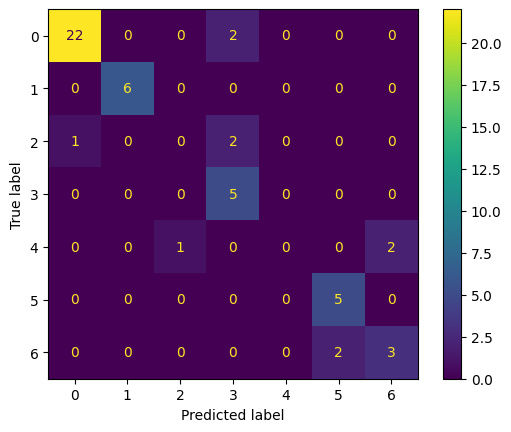

      animal       Actual    Predicted
66  porpoise       mammal         fish
76  seasnake      reptile         fish
89      toad    amphibian      reptile
26      frog    amphibian  invertebrae
72  scorpion  invertebrae       insect
91   tuatara      reptile       mammal
53   octopus  invertebrae       insect
19   dolphin       mammal         fish
25      frog    amphibian  invertebrae
62  pitviper      reptile         fish
k value = 3, accuracy = 0.686
k value = 5, accuracy = 0.686
k value = 7, accuracy = 0.686
k value = 11, accuracy = 0.686
k value = 15, accuracy = 0.686
k value = 25, accuracy = 0.686
k value = 31, accuracy = 0.686
k value = 41, accuracy = 0.588


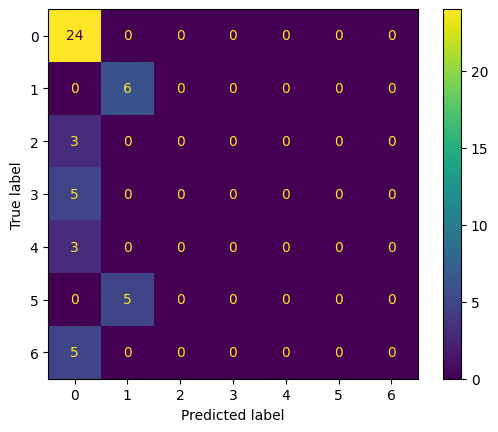

      animal       Actual Predicted
39  honeybee       insect      bird
18   dogfish         fish    mammal
30      gnat       insect      bird
97      wasp       insect      bird
77   seawasp  invertebrae    mammal
12      chub         fish    mammal
76  seasnake      reptile    mammal
89      toad    amphibian    mammal
26      frog    amphibian    mammal
42  ladybird       insect      bird
15  crayfish  invertebrae    mammal
40  housefly       insect      bird
72  scorpion  invertebrae    mammal
91   tuatara      reptile    mammal
53   octopus  invertebrae    mammal
81      slug  invertebrae    mammal
34   haddock         fish    mammal
7       carp         fish    mammal
73  seahorse         fish    mammal
25      frog    amphibian    mammal
62  pitviper      reptile    mammal


In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


df = pd.read_csv('./data/zoo.csv')
# generated class mapping dictionary after running df.loc[df['class']==index] for every value
class_mapping = {1:'mammal',
                 2: 'bird',
                 3: 'reptile',
                 4: 'fish',
                 5: 'amphibian',
                 6: 'insect',
                 7: 'invertebrae'}
print(df['class'].map(class_mapping).unique())
print(df.columns)
print(df['class'].map(class_mapping).value_counts())
print(df.describe())
# insert other EDA?

# using all columns except class
X = df.drop(columns=['animal', 'class'])
y = df['class']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
k_list = [3,5,7,11,15,25,31,41]
acc_list = []

for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    acc = accuracy_score(y_test, y_hat)
    acc_list.append(acc)

for i in range(len(k_list)):
  print(f"k value = {k_list[i]}, accuracy = {round(acc_list[i], 3)}")

# confusion matrix for k = 3 (best)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)
y_hat = model.predict(x_test)
cm = confusion_matrix(y_test, y_hat)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# misclassifications
results = x_test.copy()

results['animal'] = df.loc[x_test.index, 'animal']

results['Actual'] = y_test
results['Predicted'] = y_hat

results['Actual'] = results['Actual'].map(class_mapping)
results['Predicted'] = results['Predicted'].map(class_mapping)

mistakes = results[results['Actual'] != results['Predicted']]

print(mistakes[['animal', 'Actual', 'Predicted']])



# knn classifier with only milk, aquatic, airborne
X = df[['milk', 'aquatic', 'airborne']]
y = df['class']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
k_list = [3,5,7,11,15,25,31,41]
acc_list = []

for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    acc = accuracy_score(y_test, y_hat)
    # something missing
    acc_list.append(acc)

for i in range(len(k_list)):
  print(f"k value = {k_list[i]}, accuracy = {round(acc_list[i], 3)}")

# confusion matrix for k = 3 (best)
model = KNeighborsClassifier(n_neighbors=k)
model.fit(x_train, y_train)
y_hat = model.predict(x_test)
cm = confusion_matrix(y_test, y_hat)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# probabilities
probs = model.predict_proba(x_test)

prob_df = pd.DataFrame(
    probs,
    columns=[class_mapping[i] for i in model.classes_]
)

# misclassifications
results = x_test.copy()

results['animal'] = df.loc[x_test.index, 'animal']

results['Actual'] = y_test
results['Predicted'] = y_hat

results['Actual'] = results['Actual'].map(class_mapping)
results['Predicted'] = results['Predicted'].map(class_mapping)

mistakes = results[results['Actual'] != results['Predicted']]

print(mistakes[['animal', 'Actual', 'Predicted']])




**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)